# Great-Circle Route Map Demo

This notebook turns a route request into a deterministic great-circle map.

Phase 2 note: the notebook now calls the app-layer wrapper and receives an `ArtifactResult` instead of working directly with the raw graph dictionary.


## Setup

In [1]:
from notebook_bootstrap import (
    display_image,
    image_files,
    init_notebook,
)

ctx, reg = init_notebook()

REPO_ROOT = ctx.repo_root
PROJECT_ROOT = ctx.project_root
SRC_ROOT = ctx.src_root
PACKAGE_SRC = ctx.package_src
CACHE = ctx.cache
RESULTS = ctx.results

CACHE_POLICY = "reuse"
ALLOW_EXTERNAL_CALLS = False

/opt/anaconda3/envs/ai_py312/lib/python3.12/site-packages/bitsandbytes/cextension.py:34: UserWarning: The installed version of bitsandbytes was compiled without GPU support. 8-bit optimizers, 8-bit multiplication, and GPU quantization are unavailable.
  warn("The installed version of bitsandbytes was compiled without GPU support. "


'NoneType' object has no attribute 'cadam32bit_grad_fp32'
Repo root: /Users/douglasdaly/GitHub/Generative-AI
Project root: /Users/douglasdaly/GitHub/Generative-AI
Package src: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal
Cache: /Users/douglasdaly/GitHub/Generative-AI/src/genai_demos/agentic_multimodal/cache
Results: /Users/douglasdaly/GitHub/Generative-AI/results/agentic_multimodal
Legacy artifact roots: ['/Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-multimodal/artifacts']
Legacy cache roots: ['/Users/douglasdaly/GitHub/Generative-AI/Projects/agentic-multimodal/cache']


## Demo parameters

In [2]:
QUESTION = "Show me the flight path from Rome, GA to Rome, Italy"

# Other examples:
# QUESTION = "Show the route from Portland, Oregon to Tokyo, Japan"
# QUESTION = "Map the great-circle path from Seattle to Sydney"


## Run the route-map app

flag_stats: {'markers': 2, 'has_flag_url': 0, 'thumb_resolved': 0, 'flag_loaded': 0, 'flag_drawn': 0, 'flag_skipped_too_close': 0, 'fallback_dot': 2}
great_circle_route_map: Show me the flight path from Rome, GA to Rome, Italy (created) -> artifacts/maps/Flight Path_ Rome_ GA _ Rome_ Italy __5_038 mi_.png


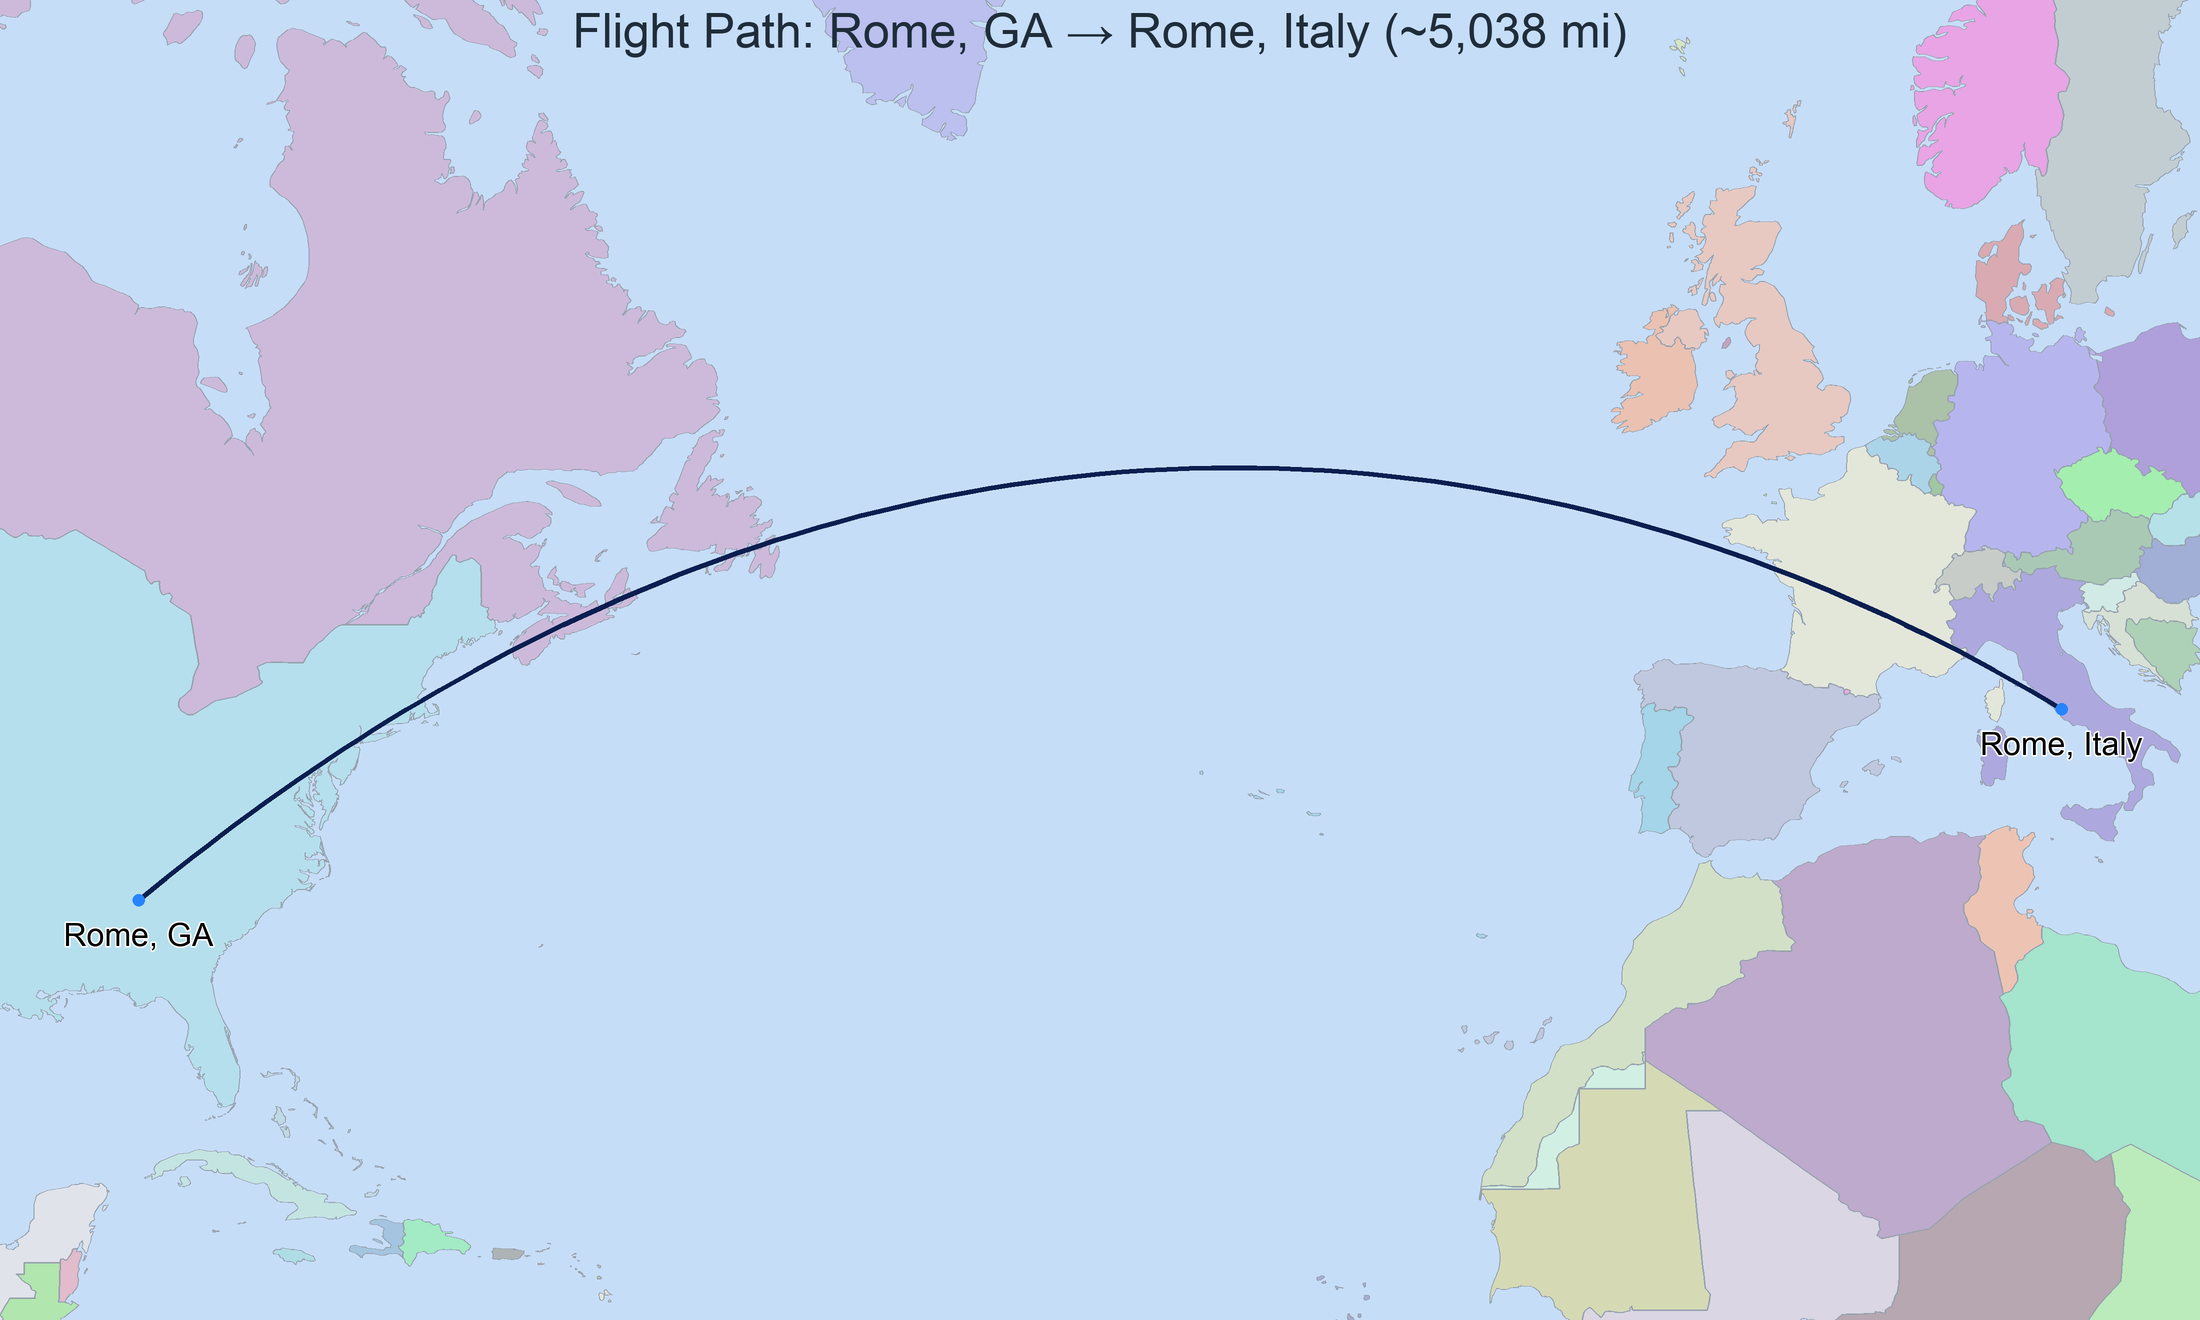

In [3]:
from pprint import pprint
from agentic_multimodal.apps.great_circle_route_map import run_great_circle_route_map

result = run_great_circle_route_map(
    reg=reg,
    question=QUESTION,
    cache_policy=CACHE_POLICY,
    allow_external_calls=ALLOW_EXTERNAL_CALLS,
)

print(result.summary())
display_image(result.path)


## Inspect result trace

In [4]:
pprint(result.to_dict())

{'cache_hits': {},
 'cache_misses': {},
 'cache_summary': {'allow_external_calls': False,
                   'cache_behavior': 'graph_owned',
                   'cache_policy': 'reuse',
                   'cache_policy_enforced': False,
                   'description': 'Reuse cached assets only. Missing assets '
                                  'are reported.'},
 'exists': True,
 'kind': 'great_circle_route_map',
 'path': 'artifacts/maps/Flight Path_ Rome_ GA _ Rome_ Italy __5_038 mi_.png',
 'title': 'Show me the flight path from Rome, GA to Rome, Italy',
 'trace': {'allow_external_calls': False,
           'answer': 'OK',
           'artifact_path': 'artifacts/maps/Flight Path_ Rome_ GA _ Rome_ '
                            'Italy __5_038 mi_.png',
           'cache_behavior': 'graph_owned',
           'cache_policy': 'reuse',
           'cache_policy_description': 'Reuse cached assets only. Missing '
                                       'assets are reported.',
           'cache_p

## Smoke checks

In [5]:
assert result.exists
assert result.kind == "great_circle_route_map"
assert result.trace["question"] == QUESTION
assert result.path.suffix.lower() in {".png", ".jpg", ".jpeg", ".webp"}

print("Great-circle route app smoke checks passed.")


Great-circle route app smoke checks passed.


## Implementation notes

- The graph still owns intent parsing and route orchestration.
- The app wrapper converts the graph's raw dictionary into a consistent `ArtifactResult`.
- The notebook stays focused on parameters, execution, display, and trace inspection.
- A future cleanup could move parsed locations, coordinates, and distance into a more structured route trace if the graph returns them consistently.
